In [28]:
# IMPORTS
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from docx import Document
from docx.shared import Inches, Pt, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT, WD_CELL_VERTICAL_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [29]:
# CONFIG
CSV_PATH = "titanic.csv"
OUTPUT_DOCX = "titanic_big_report.docx"
FIG_DIR = "report_figures"

os.makedirs(FIG_DIR, exist_ok=True)

In [30]:
# 3. LOAD DATA
df = pd.read_csv(CSV_PATH)

print("Размер:", df.shape)
print("Колонки:")
print(df.columns.tolist())
df.head()

Размер: (891, 12)
Колонки:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
# ЯВНОЕ УКАЗАНИЕ КОЛОНОК
all_columns = [
    "PassengerId",
    "Survived",
    "Pclass",
    "Name",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Ticket",
    "Fare",
    "Cabin",
    "Embarked",
]

target_col = "Survived"

drop_cols = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin",
]

numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

categorical_features = [
    "Sex",
    "Embarked",
]

print("Все колонки:", all_columns)
print("Целевая колонка:", target_col)
print("Удаляемые колонки:", drop_cols)
print("Числовые колонки:", numeric_features)
print("Категориальные колонки:", categorical_features)

Все колонки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Целевая колонка: Survived
Удаляемые колонки: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Числовые колонки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Категориальные колонки: ['Sex', 'Embarked']


In [32]:
# ПОДГОТОВКА ДАННЫХ
X = df[numeric_features + categorical_features].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (891, 7)
y shape: (891,)


,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked
0,3,22.0,1,0,7.2500,male,S
1,1,38.0,1,0,71.2833,female,C
2,3,26.0,0,0,7.9250,female,S
3,1,35.0,1,0,53.1000,female,S
4,3,35.0,0,0,8.0500,male,S


In [33]:
# ПРОПУСКИ
missing_info = df[all_columns].isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)
missing_info

Cabin       687
Age         177
Embarked      2
dtype: int64

In [34]:
# PLOTTING HELPERS
def save_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.close()

def save_figure(path=None):
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_target_distribution(df):
    counts = df["Survived"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    plt.bar(["No", "Yes"], counts.values)
    plt.title("Survival Distribution")
    plt.xlabel("Survived")
    plt.ylabel("Count")

    for i, v in enumerate(counts.values):
        plt.text(i, v + 5, str(v), ha="center")

    save_figure(os.path.join(FIG_DIR, "01_survival_distribution.png"))


def plot_sex_survival(df):
    grp = pd.crosstab(df["Sex"], df["Survived"])

    plt.figure(figsize=(8, 5))
    x = np.arange(len(grp.index))
    width = 0.35

    plt.bar(x - width / 2, grp[0].values, width, label="No")
    plt.bar(x + width / 2, grp[1].values, width, label="Yes")

    plt.xticks(x, grp.index)
    plt.xlabel("Sex")
    plt.ylabel("Count")
    plt.title("Survival by Sex")
    plt.legend()

    save_figure(os.path.join(FIG_DIR, "02_survival_by_sex.png"))


def plot_pclass_survival(df):
    grp = pd.crosstab(df["Pclass"], df["Survived"])

    plt.figure(figsize=(8, 5))
    x = np.arange(len(grp.index))
    width = 0.35

    plt.bar(x - width / 2, grp[0].values, width, label="No")
    plt.bar(x + width / 2, grp[1].values, width, label="Yes")

    plt.xticks(x, grp.index)
    plt.xlabel("Passenger Class")
    plt.ylabel("Count")
    plt.title("Survival by Passenger Class")
    plt.legend()

    save_figure(os.path.join(FIG_DIR, "03_survival_by_class.png"))


def plot_age_distribution(df):
    plt.figure(figsize=(8, 5))
    ages = df["Age"].dropna()
    plt.hist(ages, bins=25)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    save_figure(os.path.join(FIG_DIR, "04_age_distribution.png"))


def plot_fare_distribution(df):
    plt.figure(figsize=(8, 5))
    fares = df["Fare"].dropna()
    plt.hist(fares, bins=30)
    plt.title("Fare Distribution")
    plt.xlabel("Fare")
    plt.ylabel("Frequency")
    save_figure(os.path.join(FIG_DIR, "05_fare_distribution.png"))


def plot_correlation_heatmap(df):
    corr_df = df[numeric_features + [target_col]].copy()
    corr = corr_df.corr()

    plt.figure(figsize=(9, 7))
    im = plt.imshow(corr, aspect="auto")
    plt.colorbar(im)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    save_figure(os.path.join(FIG_DIR, "06_correlation_matrix.png"))


def plot_metrics_comparison(metrics_df):
    metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]

    for metric in metric_cols:
        plt.figure(figsize=(8, 5))
        plt.bar(metrics_df["Model"], metrics_df[metric])
        plt.ylim(0, 1)
        plt.title(f"{metric} Comparison")
        plt.xlabel("Model")
        plt.ylabel(metric)

        for i, v in enumerate(metrics_df[metric]):
            plt.text(i, min(v + 0.01, 0.98), f"{v:.3f}", ha="center")

        save_figure(os.path.join(FIG_DIR, f"comparison_{metric.lower()}.png"))


def plot_feature_importance_random_forest(model_pipeline, feature_names):
    rf = model_pipeline.named_steps["model"]
    importances = rf.feature_importances_

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1])
    plt.title("Random Forest Feature Importance (Top 15)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    save_figure(os.path.join(FIG_DIR, "rf_feature_importance.png"))


def plot_confusion_matrix(cm, labels, title, filename):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=12,
            )

    save_figure(os.path.join(FIG_DIR, filename))


def plot_roc_curve_single(fpr, tpr, roc_auc, title, filename):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    save_figure(os.path.join(FIG_DIR, filename))


def plot_prediction_distribution(y_prob, title, filename):
    plt.figure(figsize=(7, 5))
    plt.hist(y_prob, bins=20)
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(title)
    save_figure(os.path.join(FIG_DIR, filename))

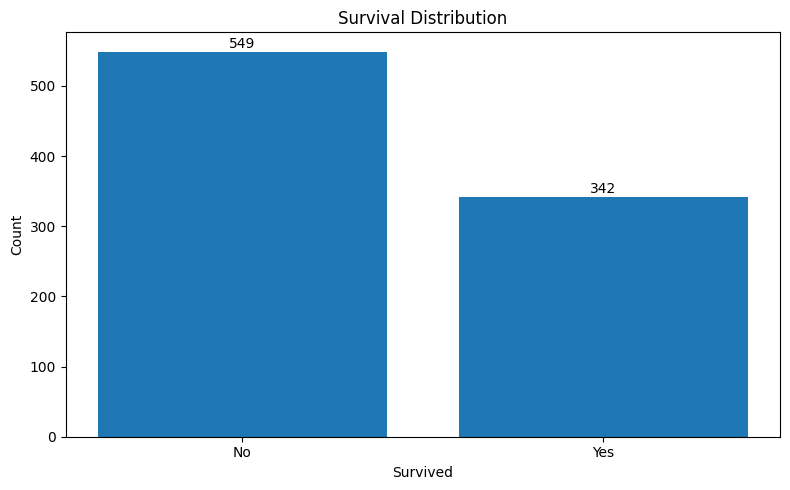

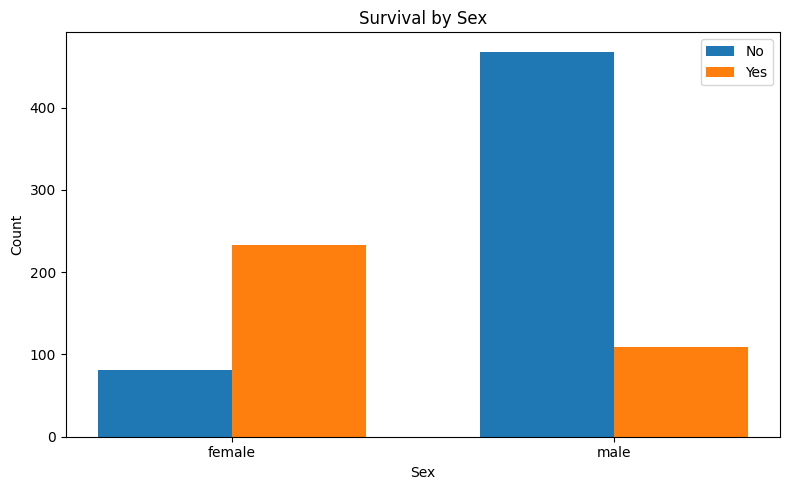

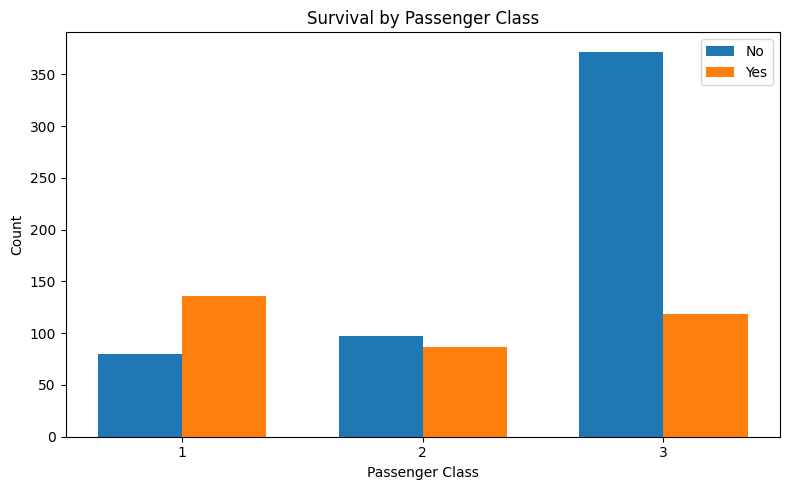

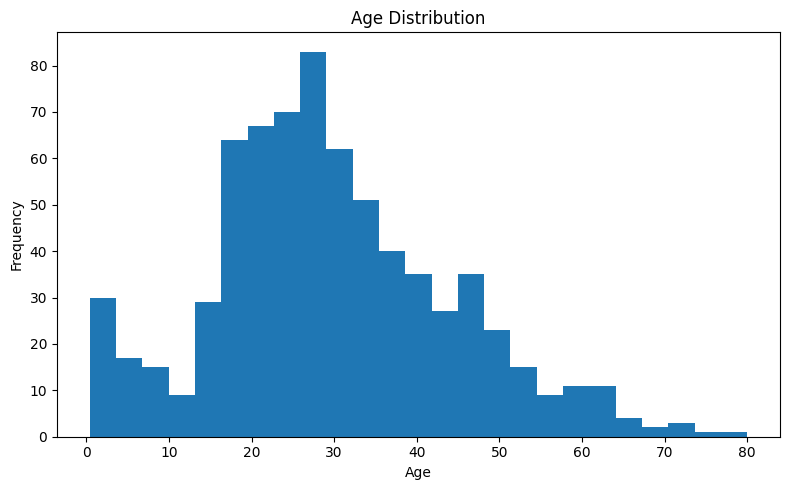

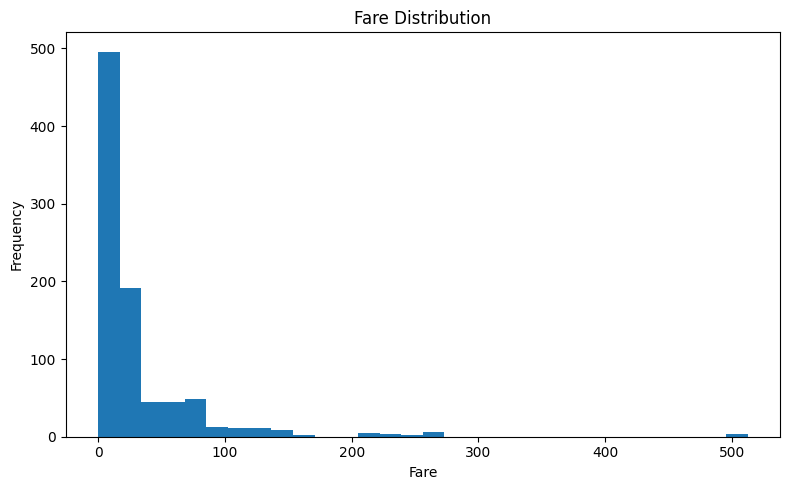

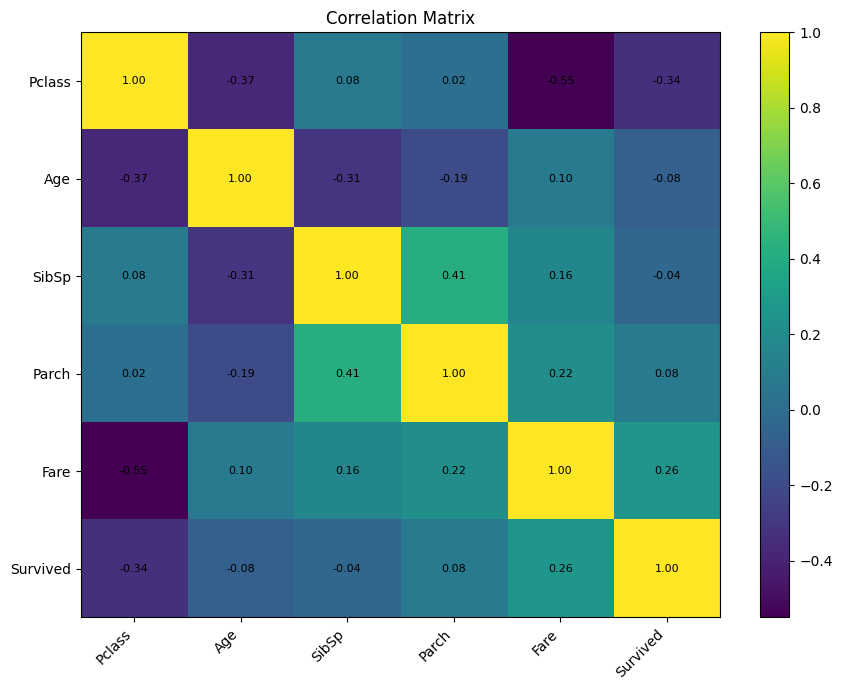

EDA графики сохранены в папке: report_figures


In [35]:
# EDA
plot_target_distribution(df)
plot_sex_survival(df)
plot_pclass_survival(df)
plot_age_distribution(df)
plot_fare_distribution(df)
plot_correlation_heatmap(df)

print("EDA графики сохранены в папке:", FIG_DIR)

In [36]:
# PREPROCESSING
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (712, 7) (712,)
Test: (179, 7) (179,)


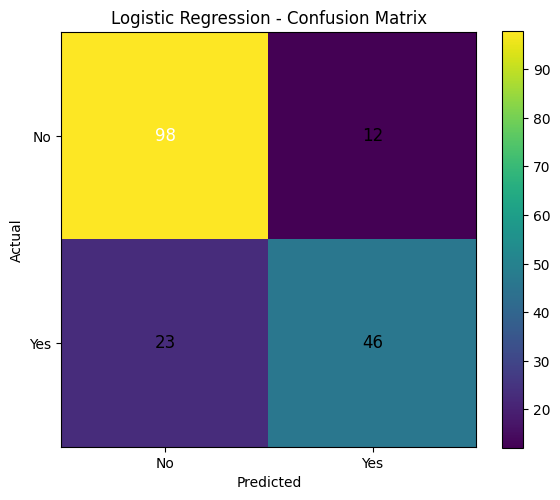

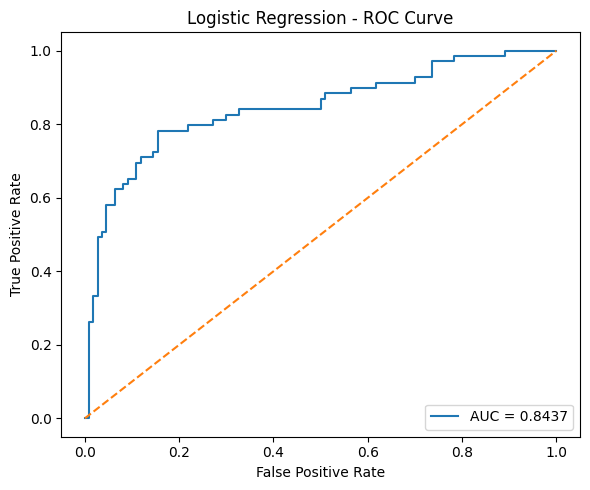

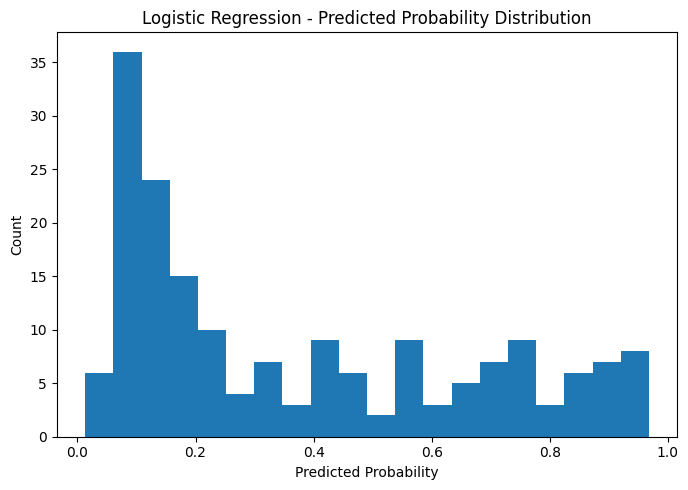

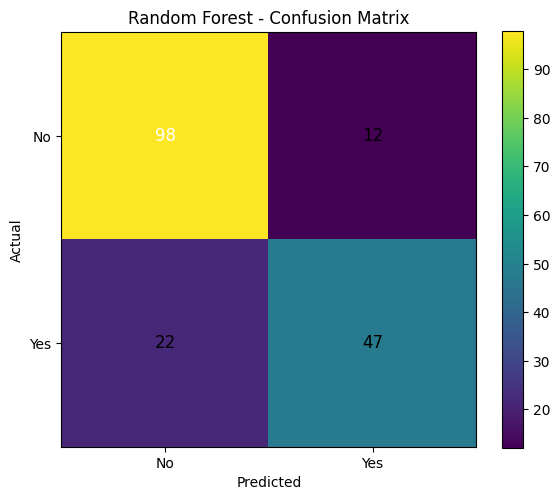

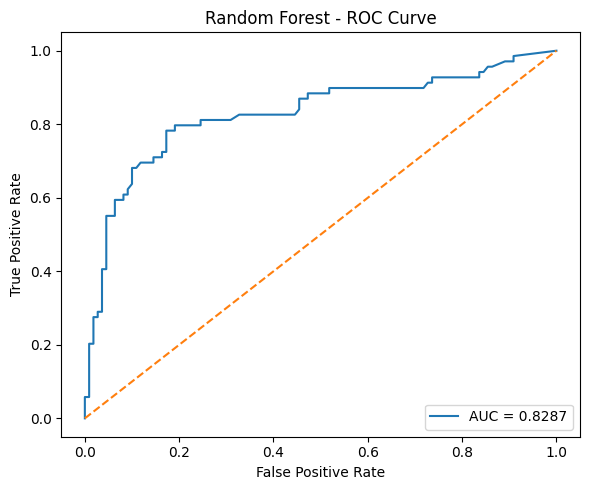

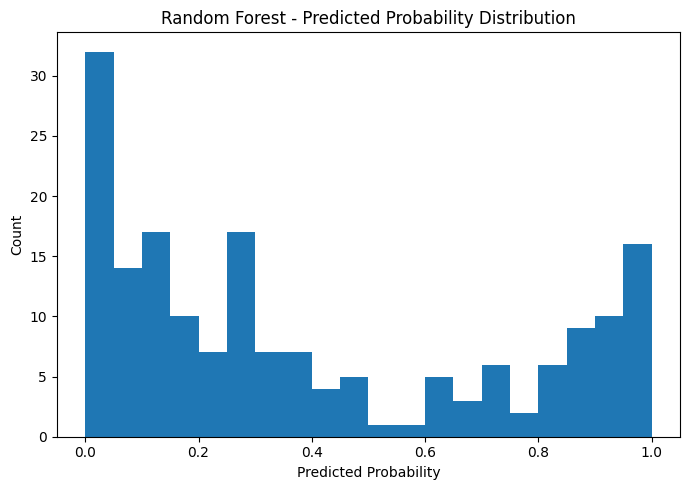

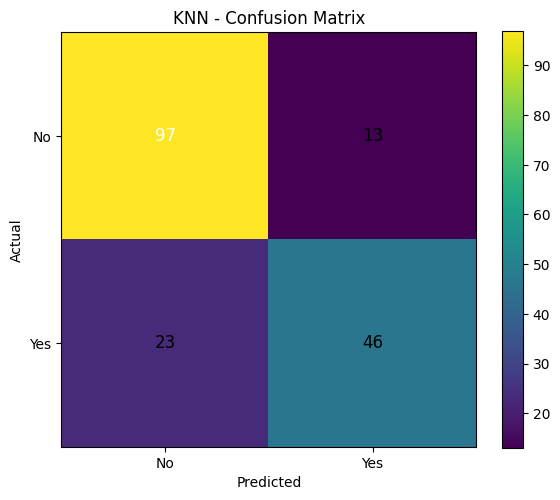

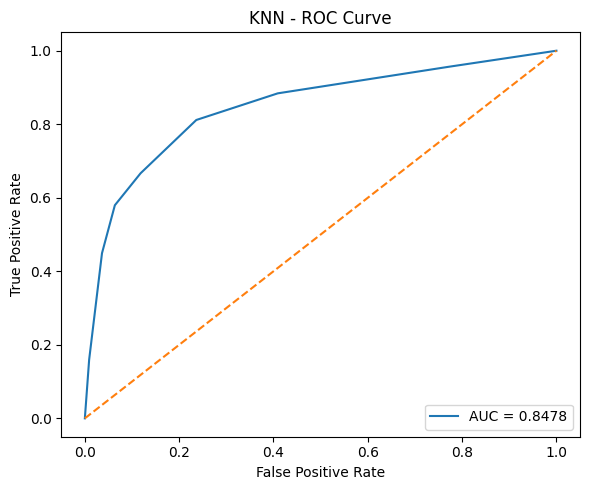

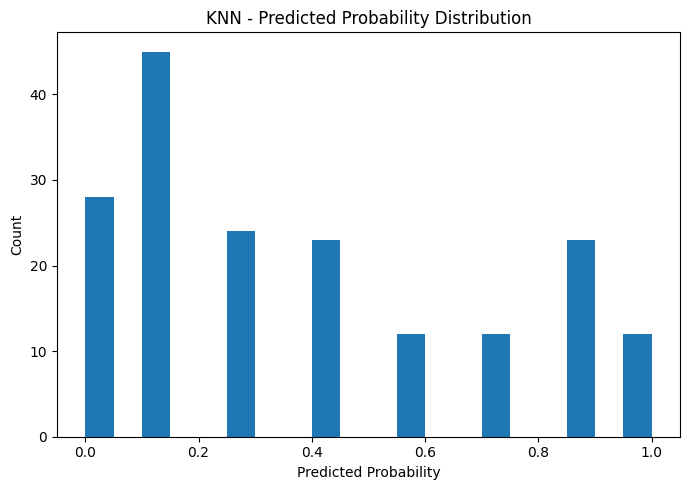

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,KNN,0.798883,0.779661,0.666667,0.718750,0.847826
1,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
2,Random Forest,0.810056,0.796610,0.681159,0.734375,0.828722


In [37]:
# MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    safe_name = model_name.lower().replace(" ", "_")

    plot_confusion_matrix(
        cm,
        labels=["No", "Yes"],
        title=f"{model_name} - Confusion Matrix",
        filename=f"{safe_name}_cm.png"
    )

    plot_roc_curve_single(
        fpr,
        tpr,
        roc_auc,
        title=f"{model_name} - ROC Curve",
        filename=f"{safe_name}_roc.png"
    )

    plot_prediction_distribution(
        y_prob,
        title=f"{model_name} - Predicted Probability Distribution",
        filename=f"{safe_name}_prob_dist.png"
    )

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc_auc,
    })

    trained_pipelines[model_name] = pipeline

metrics_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
metrics_df

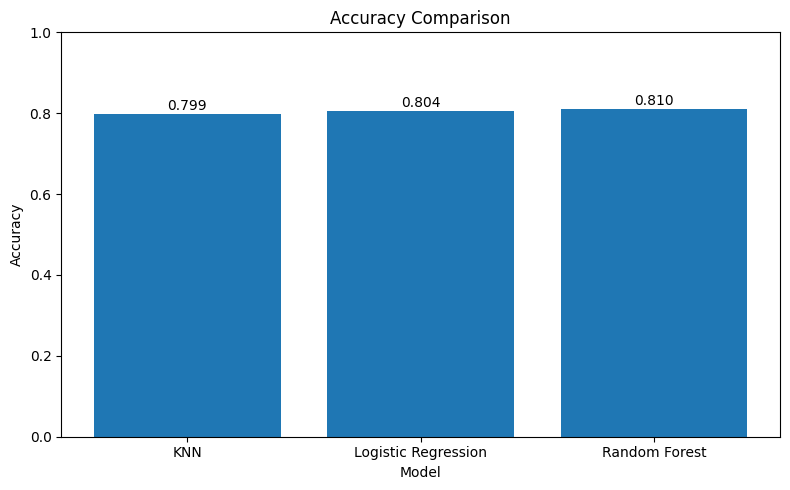

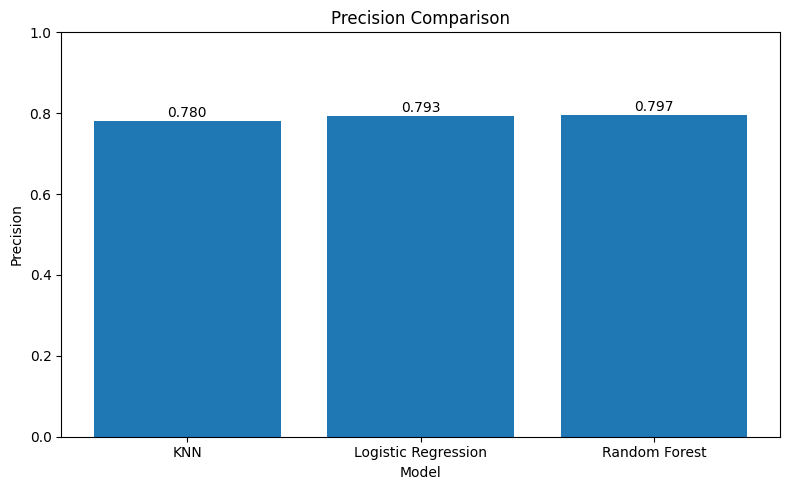

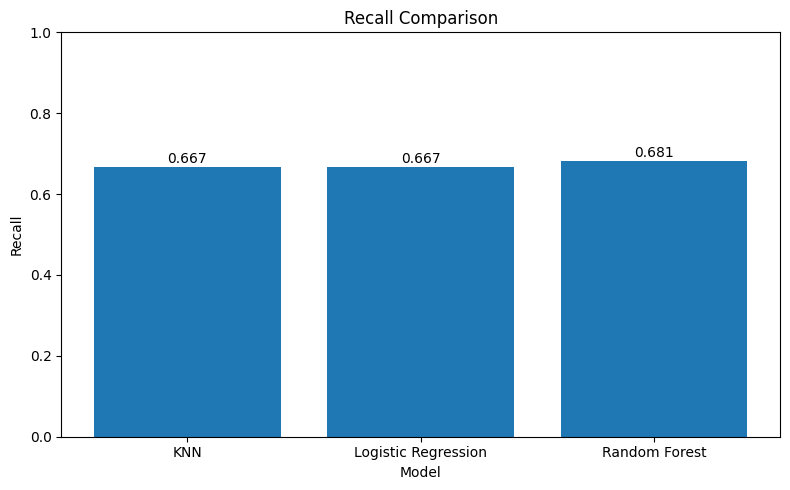

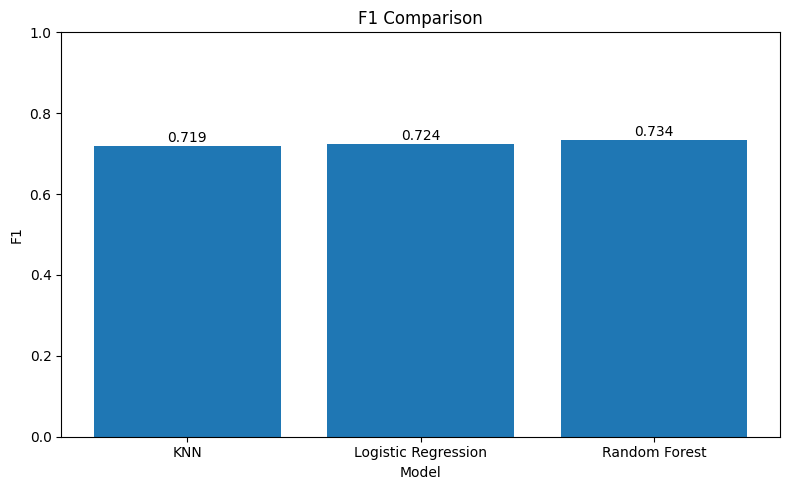

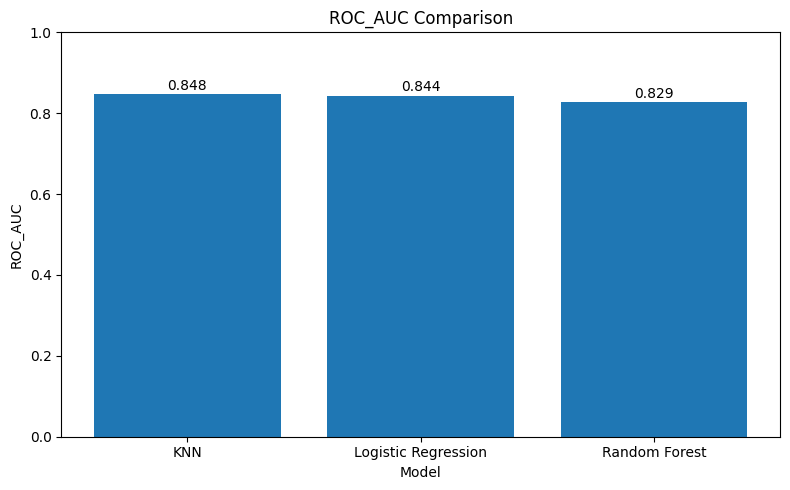

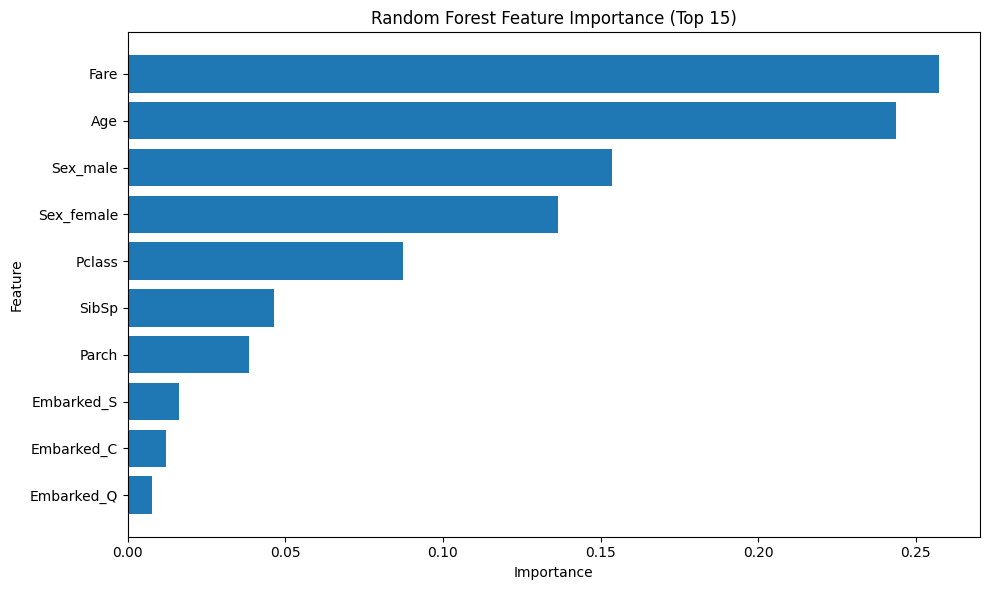

Лучшая модель: KNN
{'Model': 'KNN', 'Accuracy': 0.7988826815642458, 'Precision': 0.7796610169491526, 'Recall': 0.6666666666666666, 'F1': 0.71875, 'ROC_AUC': 0.8478260869565217}


In [38]:
# COMPARISON
plot_metrics_comparison(metrics_df)

rf_pipeline = trained_pipelines["Random Forest"]
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names_after_encoding = numeric_features + cat_feature_names

plot_feature_importance_random_forest(rf_pipeline, all_feature_names_after_encoding)

best_model_name = metrics_df.iloc[0]["Model"]
best_model_row = metrics_df.iloc[0].to_dict()

print("Лучшая модель:", best_model_name)
print(best_model_row)

In [39]:
# ВЫВОДЫ
print("Метрики по моделям:")
display(metrics_df)

print("\nЛучшая модель по ROC-AUC:", best_model_name)
print(
    f"Accuracy = {best_model_row['Accuracy']:.4f}, "
    f"Precision = {best_model_row['Precision']:.4f}, "
    f"Recall = {best_model_row['Recall']:.4f}, "
    f"F1 = {best_model_row['F1']:.4f}, "
    f"ROC-AUC = {best_model_row['ROC_AUC']:.4f}"
)

Метрики по моделям:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,KNN,0.798883,0.779661,0.666667,0.718750,0.847826
1,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
2,Random Forest,0.810056,0.796610,0.681159,0.734375,0.828722



Лучшая модель по ROC-AUC: KNN
Accuracy = 0.7989, Precision = 0.7797, Recall = 0.6667, F1 = 0.7188, ROC-AUC = 0.8478


In [40]:
# ЧТО ВЛИЯЛО НА ВЫЖИВАНИЕ

# Выживаемость по полу
sex_survival = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

# Выживаемость по классу
pclass_survival = df.groupby("Pclass")["Survived"].mean().sort_index()

# Выживаемость по порту посадки
embarked_survival = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)

# Возрастные группы
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)
agegroup_survival = df.groupby("AgeGroup")["Survived"].mean()

# Группы по стоимости билета
df["FareGroup"] = pd.qcut(df["Fare"], q=4, duplicates="drop")
faregroup_survival = df.groupby("FareGroup")["Survived"].mean()

print("Выживаемость по полу:")
display(sex_survival)

print("\nВыживаемость по классу:")
display(pclass_survival)

print("\nВыживаемость по Embarked:")
display(embarked_survival)

print("\nВыживаемость по возрастным группам:")
display(agegroup_survival)

print("\nВыживаемость по группам Fare:")
display(faregroup_survival)

Выживаемость по полу:


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


Выживаемость по классу:


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


Выживаемость по Embarked:


Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


Выживаемость по возрастным группам:


AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.382682
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


Выживаемость по группам Fare:


FareGroup
(-0.001, 7.91]     0.197309
(7.91, 14.454]     0.303571
(14.454, 31.0]     0.454955
(31.0, 512.329]    0.581081
Name: Survived, dtype: float64